# Breast Cancer Classification using Machine Learning

## Objective
The objective of this project is to classify breast cancer tumors as **Benign** or **Malignant** using Machine Learning algorithms.

### Algorithms Used
- Logistic Regression
- Random Forest Classifier

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

### Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-Learn

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import joblib

In [15]:
cancer = load_breast_cancer()

df = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)

df["target"] = cancer.target

In [16]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nStatistical Summary:")
display(df.describe())

DATASET OVERVIEW

Dataset Shape:
(569, 31)

Column Names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']

Data Types:


mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      


Statistical Summary:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [17]:
print("="*60)
print("DATA QUALITY CHECK")
print("="*60)

print("\nMissing Values")

display(df.isnull().sum())

print("\nDuplicate Rows")

print(df.duplicated().sum())

print("\nDataset Information")

df.info()

DATA QUALITY CHECK

Missing Values


mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


Duplicate Rows
0

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    

In [18]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


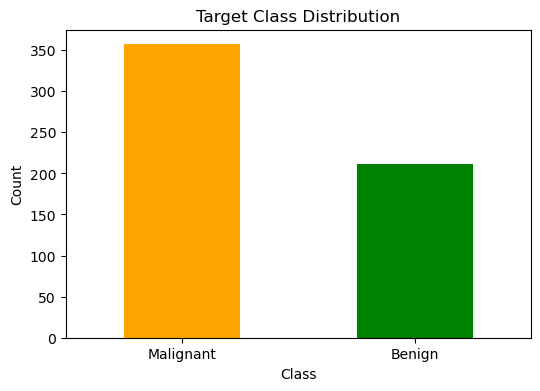

In [19]:
plt.figure(figsize=(6,4))

df["target"].value_counts().plot(
    kind="bar",
    color=["orange","green"]
)

plt.title("Target Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.xticks(
    [0,1],
    ["Malignant","Benign"],
    rotation=0
)

plt.show()

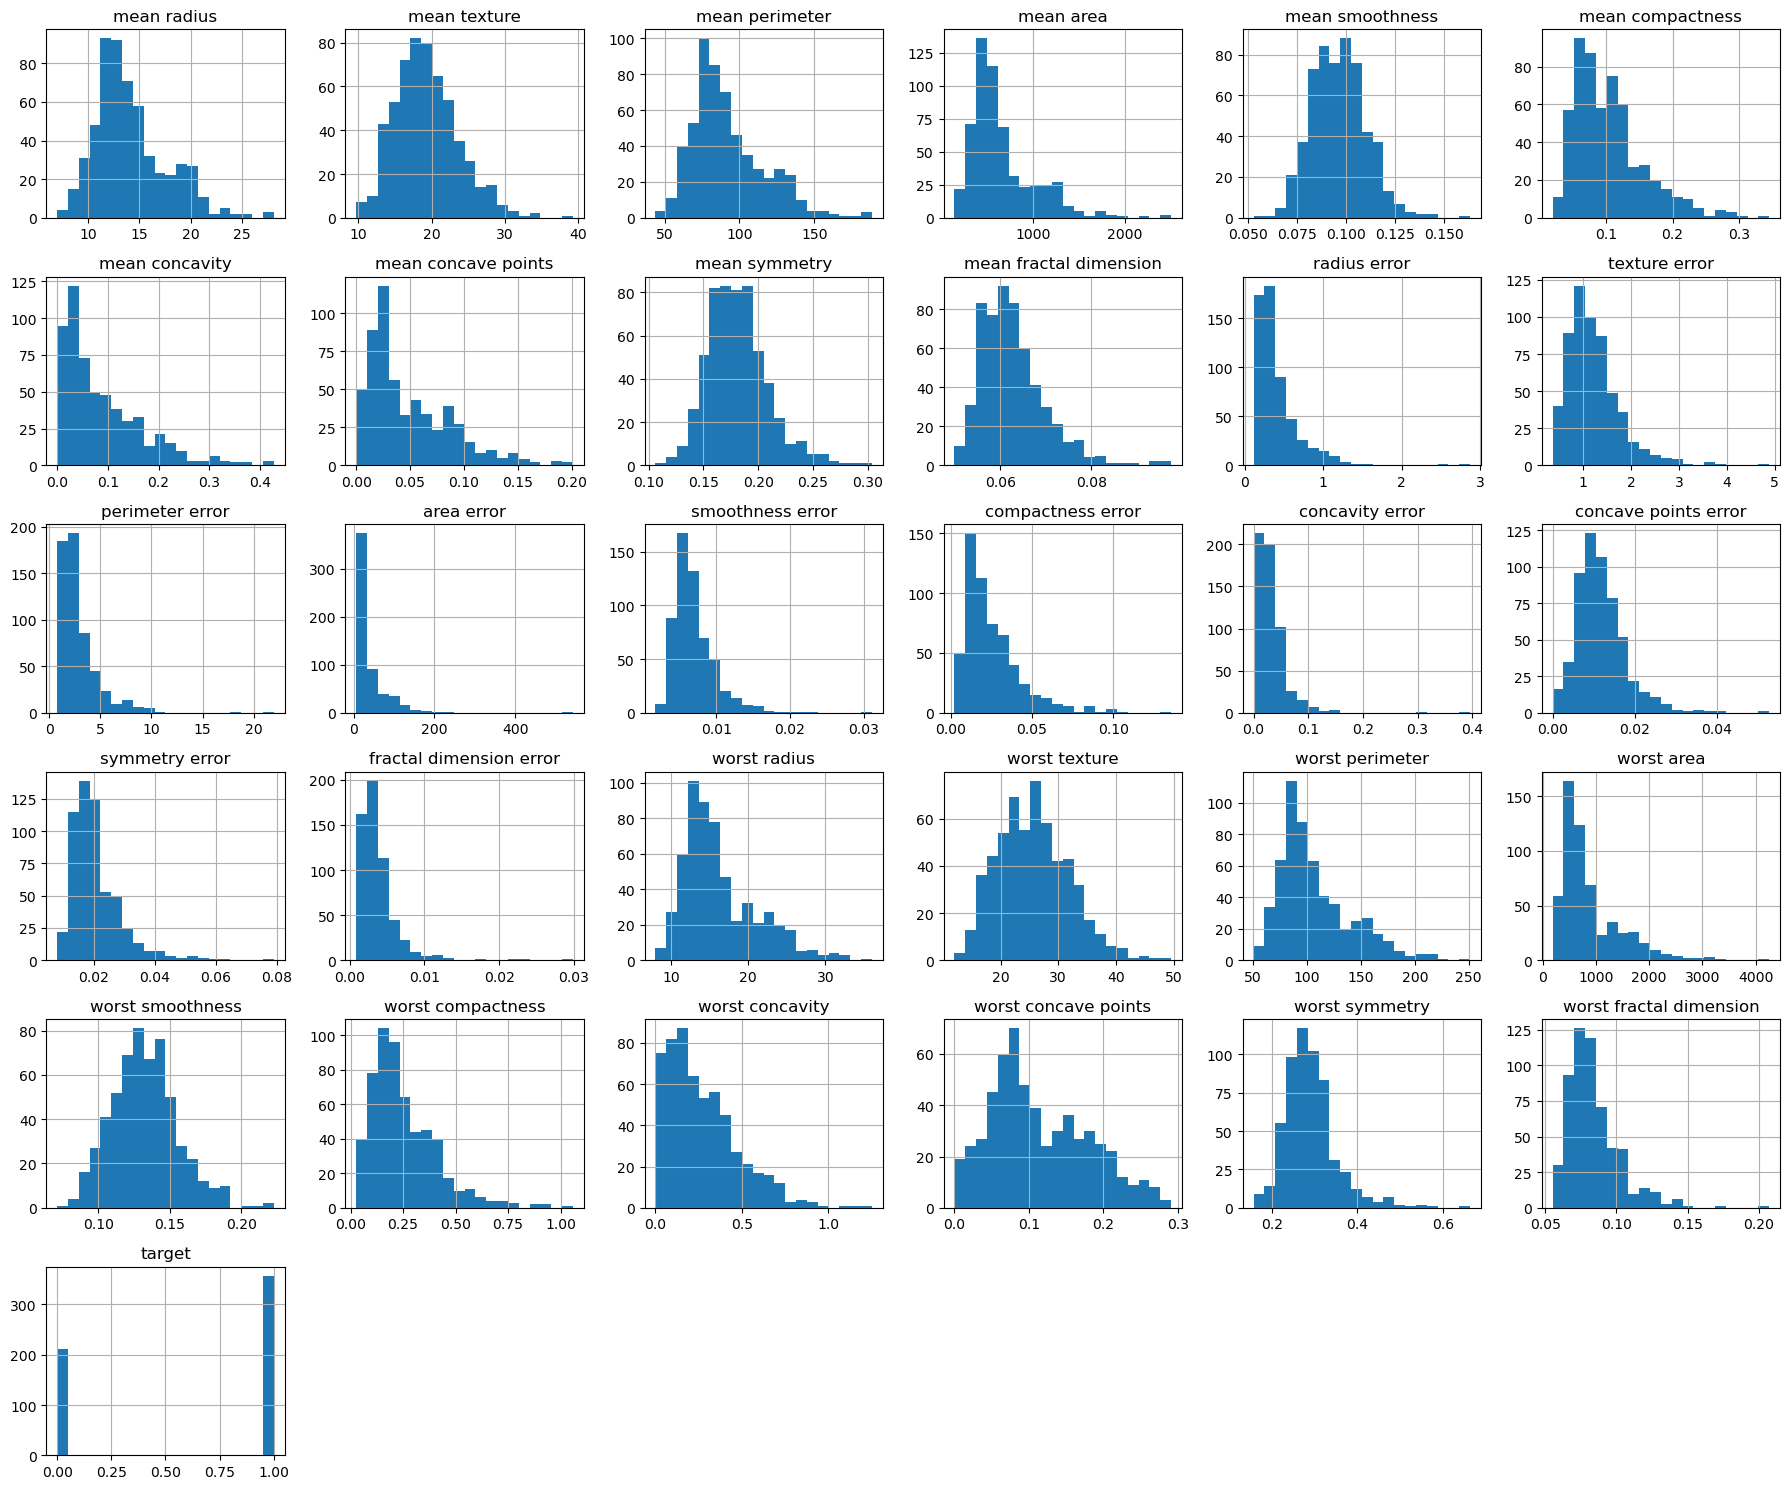

In [20]:
df.hist(
    figsize=(18,15),
    bins=20
)

plt.tight_layout()

plt.show()

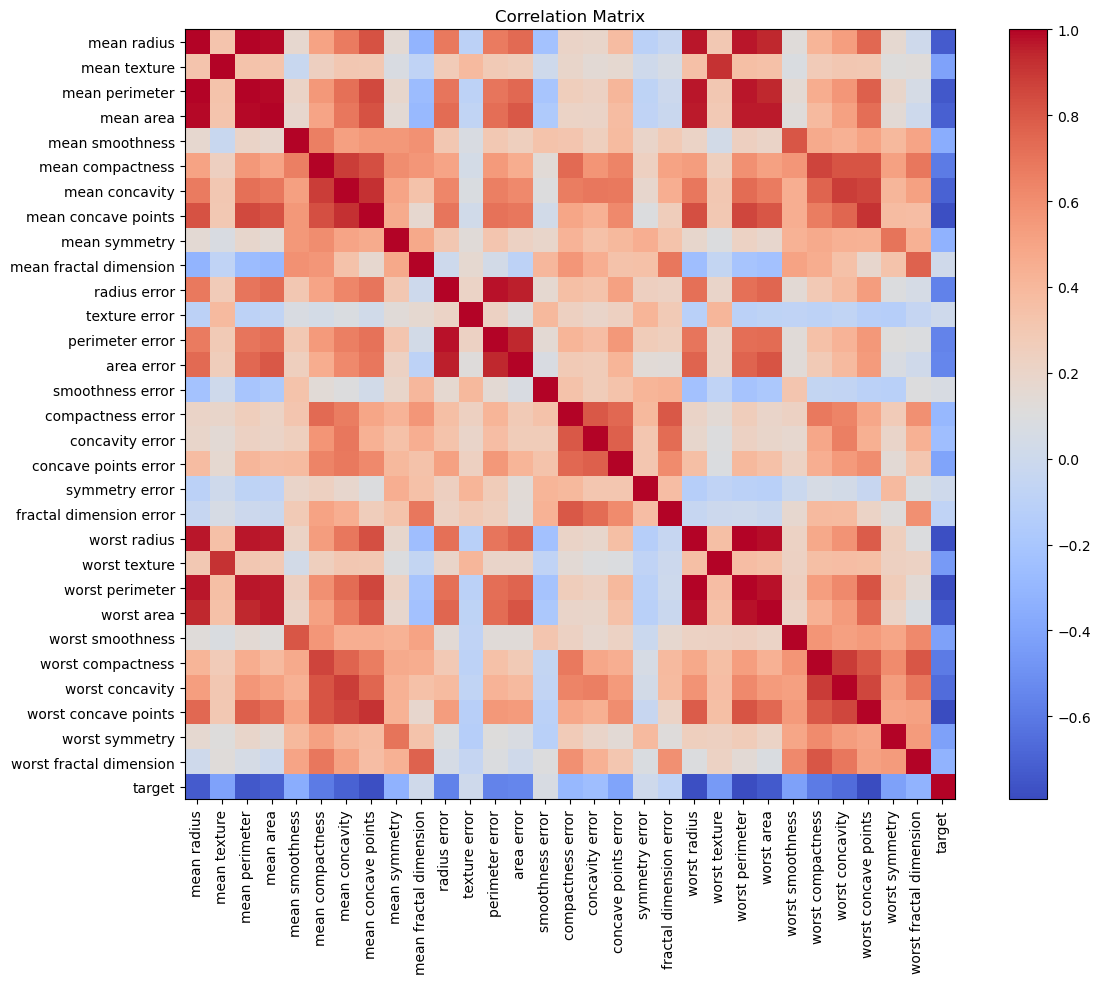

In [21]:
plt.figure(figsize=(14,10))

corr=df.corr()

plt.imshow(
    corr,
    cmap="coolwarm"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.show()

In [22]:
# Separate features and target

X = df.drop("target", axis=1)
y = df["target"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (569, 30)
Target Shape : (569,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 455
Testing Samples : 114


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


In [25]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy :", round(lr_accuracy,4))

Logistic Regression Accuracy : 0.9825


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

rf_predictions = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy :", round(rf_accuracy,4))

Random Forest Accuracy : 0.9561


In [27]:
from sklearn.model_selection import GridSearchCV

parameters = {
    "n_estimators":[50,100,200],
    "max_depth":[None,5,10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    parameters,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_scaled,y_train)

print("Best Parameters")

print(grid.best_params_)

print("\nBest Cross Validation Accuracy")

print(round(grid.best_score_,4))

Best Parameters
{'max_depth': None, 'n_estimators': 200}

Best Cross Validation Accuracy
0.9604


In [28]:
results_df = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        lr_accuracy,
        rf_accuracy
    ]

})

results_df

,Model,Accuracy
0,Logistic Regression,0.982456
1,Random Forest,0.956140


In [29]:
from sklearn.metrics import classification_report

print("="*60)

print("LOGISTIC REGRESSION")

print("="*60)

print(classification_report(
    y_test,
    lr_predictions
))

print("="*60)

print("RANDOM FOREST")

print("="*60)

print(classification_report(
    y_test,
    rf_predictions
))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



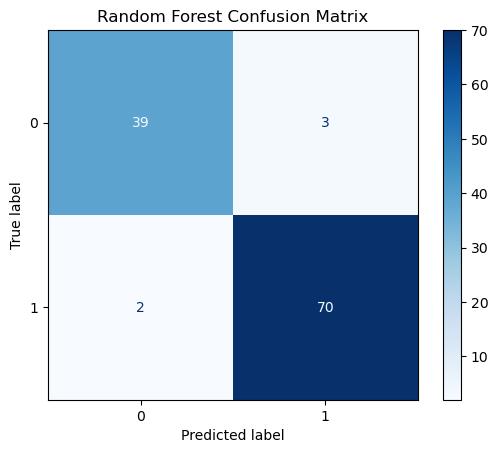

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test_scaled,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

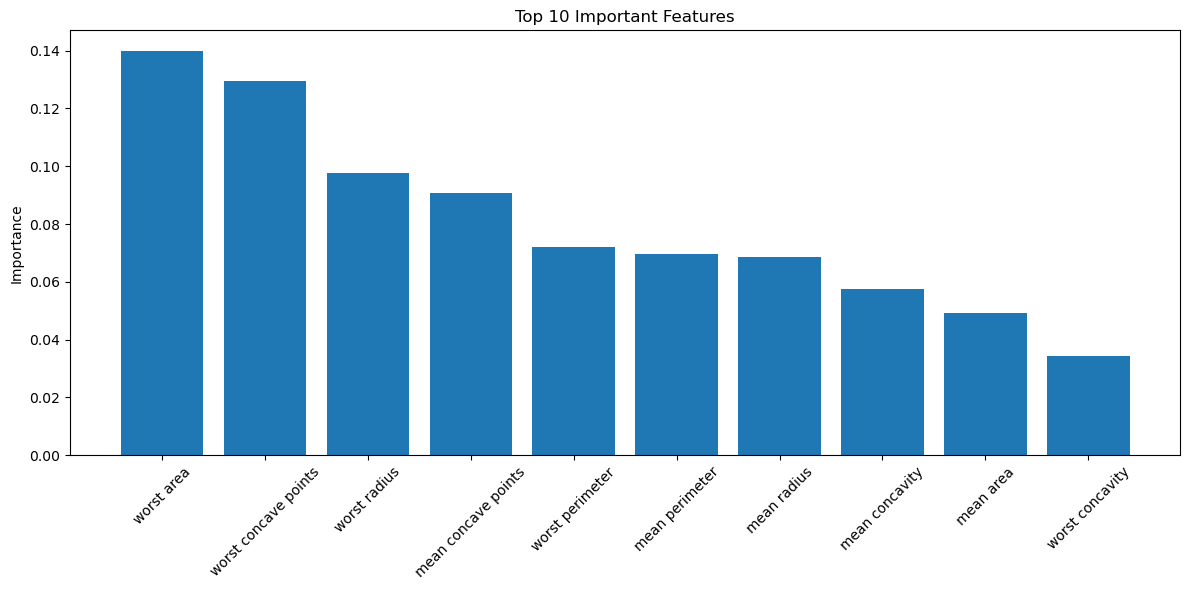

In [31]:
importance = rf_model.feature_importances_

indices = importance.argsort()[::-1]

plt.figure(figsize=(12,6))

plt.bar(
    range(10),
    importance[indices[:10]]
)

plt.xticks(
    range(10),
    X.columns[indices[:10]],
    rotation=45
)

plt.title("Top 10 Important Features")

plt.ylabel("Importance")

plt.tight_layout()

plt.show()

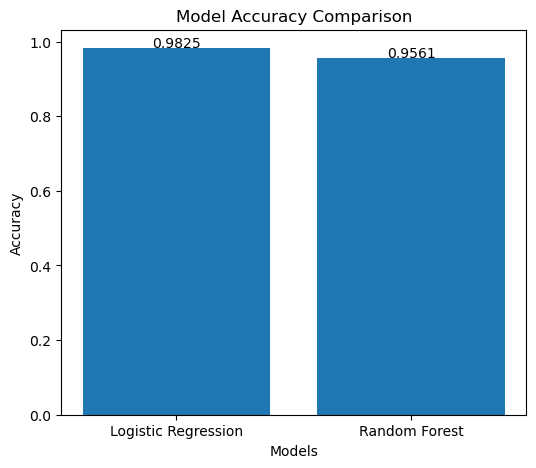

In [32]:
plt.figure(figsize=(6,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

for i, value in enumerate(results_df["Accuracy"]):
    plt.text(i, value+0.002, f"{value:.4f}", ha="center")

plt.show()

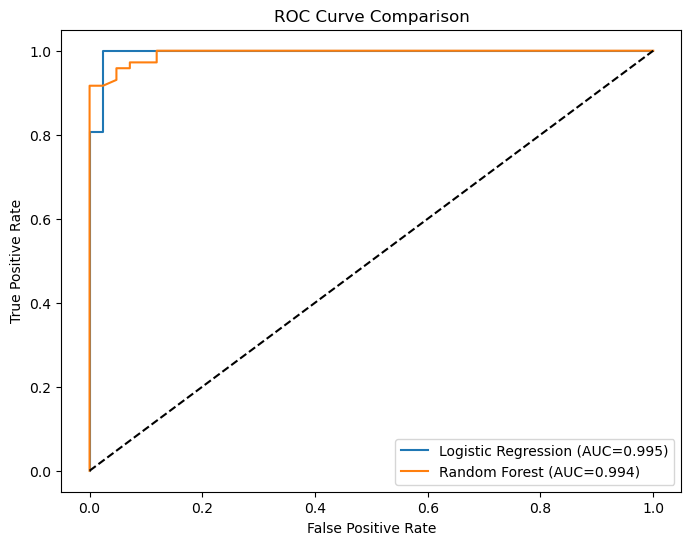

In [33]:
from sklearn.metrics import roc_curve, auc

lr_probs = lr_model.predict_proba(X_test_scaled)[:,1]
rf_probs = rf_model.predict_proba(X_test_scaled)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={lr_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={rf_auc:.3f})"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [34]:
if rf_accuracy > lr_accuracy:
    best_model = rf_model
    best_model_name = "Random Forest"
    best_accuracy = rf_accuracy
else:
    best_model = lr_model
    best_model_name = "Logistic Regression"
    best_accuracy = lr_accuracy

print("="*60)
print("BEST MODEL")
print("="*60)

print("Model :", best_model_name)
print("Accuracy :", round(best_accuracy,4))

BEST MODEL
Model : Logistic Regression
Accuracy : 0.9825


In [35]:
import joblib

joblib.dump(best_model, "breast_cancer_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully.")

Model Saved Successfully.


In [36]:
loaded_model = joblib.load("breast_cancer_model.pkl")

loaded_scaler = joblib.load("scaler.pkl")

print("Saved Model Loaded Successfully.")

Saved Model Loaded Successfully.


In [37]:
sample = X.iloc[0].values.reshape(1,-1)

sample = loaded_scaler.transform(sample)

prediction = loaded_model.predict(sample)[0]

print("Prediction Result")

if prediction == 1:
    print("Benign Tumor")
else:
    print("Malignant Tumor")

print("\nActual Class")

if y.iloc[0] == 1:
    print("Benign Tumor")
else:
    print("Malignant Tumor")

Prediction Result
Malignant Tumor

Actual Class
Malignant Tumor


C:\Jupyter\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [38]:
print("="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)

display(results_df)

print("\nBest Model :", best_model_name)

print("Best Accuracy :", round(best_accuracy,4))

print("ROC AUC (Logistic Regression) :", round(lr_auc,4))

print("ROC AUC (Random Forest) :", round(rf_auc,4))

MODEL PERFORMANCE SUMMARY


,Model,Accuracy
0,Logistic Regression,0.982456
1,Random Forest,0.956140



Best Model : Logistic Regression
Best Accuracy : 0.9825
ROC AUC (Logistic Regression) : 0.9954
ROC AUC (Random Forest) : 0.9939


# Conclusion

## Project Summary

This project successfully classified breast cancer tumors using supervised machine learning techniques.

### Models Compared
- Logistic Regression
- Random Forest Classifier

### Key Findings
- The dataset was explored and checked for missing values.
- Features were standardized before model training.
- Random Forest and Logistic Regression were trained and evaluated.
- Performance was measured using Accuracy, Classification Report, Confusion Matrix, and ROC-AUC.
- The best-performing model was saved for future predictions.

### Outcome
The Random Forest classifier achieved the highest performance and was selected as the final model for breast cancer prediction.